In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
from PDESolver import *

In [5]:
# Declaration of necessary variables
f = Function('f')
g = Function('g')

# Symbol manipulation

## Asymptotic composition

In [6]:
from sympy import symbols
x, xi = symbols('x xi')
p1 = PseudoDifferentialOperator(expr=xi + x, vars_x=[x], mode='symbol')

p2 = PseudoDifferentialOperator(expr=xi + x**2, vars_x=[x], mode='symbol')

composition_1d = p1.compose_asymptotic(p2, order=2)
print("1D Asymptotic composition:")
print(composition_1d)



symbol = 
x + ξ

symbol = 
 2    
x  + ξ
1D Asymptotic composition:
1.0*(x + xi)*(x**2 + xi)


In [7]:
x, y, xi, eta = symbols('x y xi eta')
p1 = PseudoDifferentialOperator(expr=xi**2 + eta**2 + x*y, vars_x=[x, y], mode='symbol')
p2 = PseudoDifferentialOperator(expr=xi + eta + x + y, vars_x=[x, y], mode='symbol')

composition_2d = p1.compose_asymptotic(p2, order=2)
print("2D Asymptotic composition:")
print(composition_2d)



symbol = 
 2          2
η  + x⋅y + ξ 

symbol = 
η + x + ξ + y
2D Asymptotic composition:
1.0*(eta**2 + x*y + xi**2)*(eta + x + xi + y)


## Right asymtotic inverse

In [8]:
p = PseudoDifferentialOperator(expr=xi + 1, vars_x=[x], mode='symbol')
right_inv_1d = p.right_inverse_asymptotic(order=2)
print("1D Right asymtotic inverse:")
print(right_inv_1d)
p2 = PseudoDifferentialOperator(expr=right_inv_1d, vars_x=[x], mode='symbol')
print("1D Composition rule:")
p.compose_asymptotic(p2, order=2)


symbol = 
ξ + 1
1D Right asymtotic inverse:
1/(xi + 1)

symbol = 
  1  
─────
ξ + 1
1D Composition rule:


1.00000000000000

In [9]:
p = PseudoDifferentialOperator(expr=xi + eta + 1, vars_x=[x, y], mode='symbol')
right_inv_2d = p.right_inverse_asymptotic(order=2)
print("2D Right asymtotic inverse:")
print(right_inv_2d)
p2 = PseudoDifferentialOperator(expr=right_inv_2d, vars_x=[x, y], mode='symbol')
print("2D Composition rule:")
p.compose_asymptotic(p2, order=2)


symbol = 
η + ξ + 1
2D Right asymtotic inverse:
1/(eta + xi + 1)

symbol = 
    1    
─────────
η + ξ + 1
2D Composition rule:


1.00000000000000

## Left asymtotic inverse

In [10]:
p = PseudoDifferentialOperator(expr=xi + 1, vars_x=[x], mode='symbol')
left_inv_1d = p.left_inverse_asymptotic(order=2)
print("1D Left asymtotic inverse:")
print(left_inv_1d)
p2 = PseudoDifferentialOperator(expr=left_inv_1d, vars_x=[x], mode='symbol')
print("1D Composition rule:")
p2.compose_asymptotic(p, order=2)


symbol = 
ξ + 1
1D Left asymtotic inverse:
1/(xi + 1)

symbol = 
  1  
─────
ξ + 1
1D Composition rule:


1.00000000000000

In [11]:
p = PseudoDifferentialOperator(expr=xi + eta + 1, vars_x=[x, y], mode='symbol')
left_inv_2d = p.left_inverse_asymptotic(order=3)
print("2D Left asymtotic inverse:")
print(left_inv_2d)
p2 = PseudoDifferentialOperator(expr=left_inv_2d, vars_x=[x, y], mode='symbol')
print("2D Composition rule:")
p2.compose_asymptotic(p, order=3)


symbol = 
η + ξ + 1
2D Left asymtotic inverse:
1/(eta + xi + 1)

symbol = 
    1    
─────────
η + ξ + 1
2D Composition rule:


1.00000000000000

## Ellipticity

In [12]:
x, xi = symbols('x xi', real=True)

x_vals = np.linspace(-1, 1, 100)
xi_vals = np.linspace(-10, 10, 100)

op1 = PseudoDifferentialOperator(expr=xi**2 + 1, vars_x=[x], mode='symbol')
print("1D elliptic test:", op1.is_elliptic_numerically(x_vals, xi_vals))  # True 

op2 = PseudoDifferentialOperator(expr=xi, vars_x=[x], mode='symbol')
print("1D non-elliptic test:", op2.is_elliptic_numerically(x_vals, xi_vals))  # False attendu



symbol = 
 2    
ξ  + 1
1D elliptic test: True

symbol = 
ξ
1D non-elliptic test: True


In [13]:
x_vals = np.linspace(-1, 1, 50)
y_vals = np.linspace(-1, 1, 50)
xi_vals = np.linspace(-10, 10, 50)
eta_vals = np.linspace(-10, 10, 50)

op3 = PseudoDifferentialOperator(expr=xi**2 + eta**2 + 1, vars_x=[x, y], mode='symbol')
print("2D elliptic test:", op3.is_elliptic_numerically((x_vals, y_vals), (xi_vals, eta_vals)))  # True

op4 = PseudoDifferentialOperator(expr=xi + eta, vars_x=[x, y], mode='symbol')
print("2D non-elliptic test:", op4.is_elliptic_numerically((x_vals, y_vals), (xi_vals, eta_vals)))  # False



symbol = 
 2    2    
η  + ξ  + 1
2D elliptic test: True

symbol = 
η + ξ
2D non-elliptic test: False


## $L ∘ P = Id$


symbol = 
 2    2    
x  + ξ  + 1
Left asymptotic inverse:
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                             ⎛           2                                     ↪
                             ⎜ 24.0⋅ⅈ⋅x⋅ξ         4.0⋅ⅈ⋅x            2⋅ξ       ↪
                   - 2.0⋅ⅈ⋅x⋅⎜────────────── - ────────────── - ────────────── ↪
                             ⎜             4                3                2 ↪
                             ⎜⎛ 2    2    ⎞    ⎛ 2    2    ⎞    ⎛ 2    2    ⎞  ↪
    4.0⋅ⅈ⋅x⋅ξ                ⎝⎝x  + ξ  + 1⎠    ⎝x  + ξ  + 1⎠    ⎝x  + ξ  + 1⎠  ↪
- ────────────── - ─────────────────────────────────────────────────────────── ↪
               3                                 

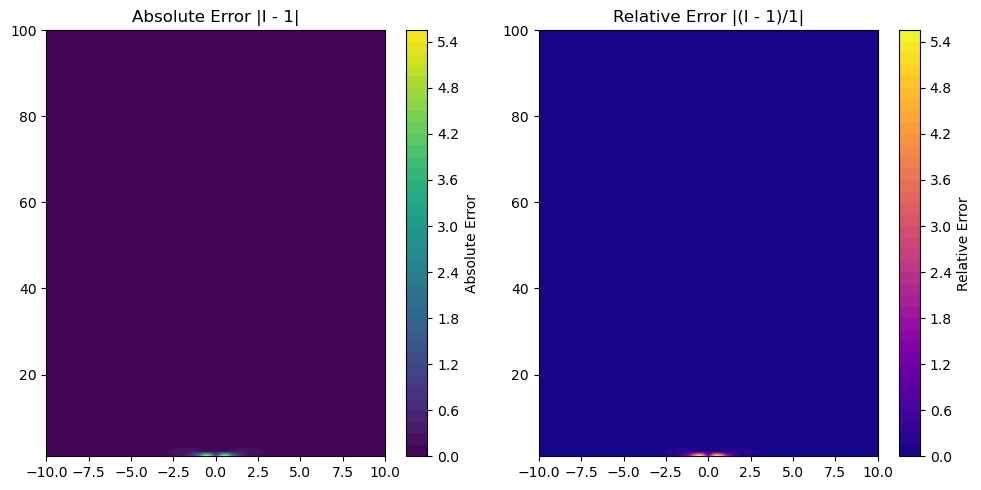

In [14]:
order = 2
# Define symbolic variables
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

# Define the pseudo-differential symbol p(x, xi)
p_symbol = xi**2 + x**2 + 1

# Create the pseudo-differential operator
p = PseudoDifferentialOperator(expr=p_symbol, vars_x=[x], mode='symbol')

# Compute the left asymptotic inverse of the operator
left_inv = p.left_inverse_asymptotic(order=order)
print("Left asymptotic inverse:")
pprint(left_inv)

# Create a new operator from the left inverse
p_left_inv = PseudoDifferentialOperator(expr=left_inv, vars_x=[x], mode='symbol')

# Verify the composition rule: L ∘ P ≈ I (identity operator)
composition = p_left_inv.compose_asymptotic(p, order=order)
print("Composition rule (L ∘ P):")
pprint(composition)

# Simplify the result to check if it approximates the identity operator
identity_approximation = simplify(composition)
print("Simplified composition (should approximate 1):")
pprint(identity_approximation)

# Development around xi -> infinity
series_expansion = series(identity_approximation, xi, oo, n=3)
print("Series expansion:", series_expansion)

# Convert to numerical function
identity_func = lambdify((x, xi), identity_approximation, 'numpy')

# Grid of points
x_vals = np.linspace(-10, 10, 100)
xi_vals = np.linspace(1, 100, 100)  # Positive frequencies
X, XI = np.meshgrid(x_vals, xi_vals, indexing='ij')

# Numerical evaluation
identity_vals = identity_func(X, XI)

absolute_error = np.abs(identity_vals - 1)
relative_error = np.abs((identity_vals - 1) / 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.contourf(X, XI, absolute_error, levels=50, cmap='viridis')
plt.colorbar(label='Absolute Error')
plt.title('Absolute Error |I - 1|')

plt.subplot(1, 2, 2)
plt.contourf(X, XI, relative_error, levels=50, cmap='plasma')
plt.colorbar(label='Relative Error')
plt.title('Relative Error |(I - 1)/1|')

plt.tight_layout()
plt.show()


## $P ∘ R = Id$


symbol = 
 2    2    
x  + ξ  + 1
Right asymptotic inverse:
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                             ⎛         2                                       ↪
                             ⎜ 24.0⋅ⅈ⋅x ⋅ξ          2⋅x            4.0⋅ⅈ⋅ξ     ↪
                   - 2.0⋅ⅈ⋅ξ⋅⎜────────────── - ────────────── - ────────────── ↪
                             ⎜             4                2                3 ↪
                             ⎜⎛ 2    2    ⎞    ⎛ 2    2    ⎞    ⎛ 2    2    ⎞  ↪
    4.0⋅ⅈ⋅x⋅ξ                ⎝⎝x  + ξ  + 1⎠    ⎝x  + ξ  + 1⎠    ⎝x  + ξ  + 1⎠  ↪
- ────────────── - ─────────────────────────────────────────────────────────── ↪
               3                                

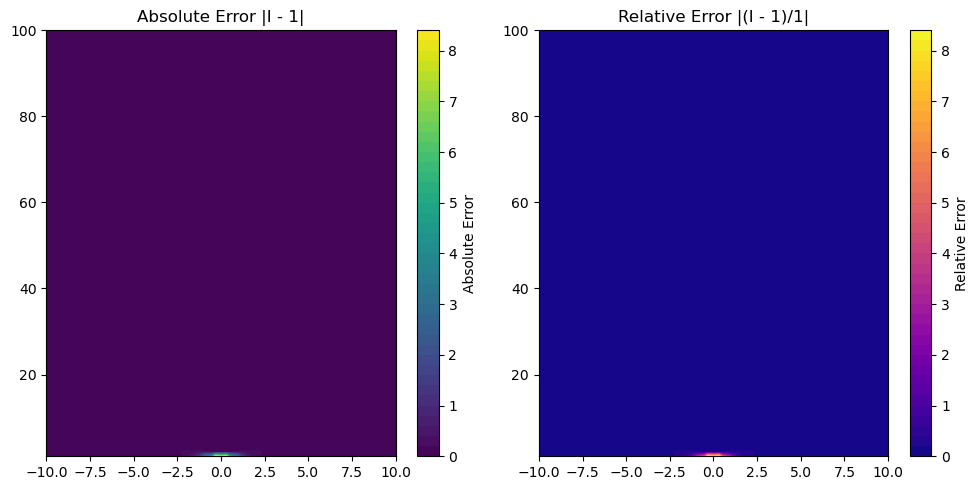

In [15]:
order = 2
# Define symbolic variables
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

# Define the pseudo-differential symbol p(x, xi)
p_symbol = xi**2 + x**2 + 1

# Create the pseudo-differential operator
p = PseudoDifferentialOperator(expr=p_symbol, vars_x=[x], mode='symbol')

# Compute the left asymptotic inverse of the operator
right_inv = p.right_inverse_asymptotic(order=order)
print("Right asymptotic inverse:")
pprint(right_inv)

# Create a new operator from the left inverse
p_right_inv = PseudoDifferentialOperator(expr=right_inv, vars_x=[x], mode='symbol')

# Verify the composition rule: L ∘ P ≈ I (identity operator)
composition = p.compose_asymptotic(p_right_inv, order=order)
print("Composition rule (P ∘ R ):")
pprint(composition)

# Simplify the result to check if it approximates the identity operator
identity_approximation = simplify(composition)
print("Simplified composition (should approximate 1):")
pprint(identity_approximation)

# Development around xi -> infinity
series_expansion = series(identity_approximation, xi, oo, n=3)
print("Series expansion:", series_expansion)

# Convert to numerical function
identity_func = lambdify((x, xi), identity_approximation, 'numpy')

# Grid of points
x_vals = np.linspace(-10, 10, 100)
xi_vals = np.linspace(1, 100, 100)  # Positive frequencies
X, XI = np.meshgrid(x_vals, xi_vals, indexing='ij')

# Numerical evaluation
identity_vals = identity_func(X, XI)

absolute_error = np.abs(identity_vals - 1)
relative_error = np.abs((identity_vals - 1) / 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.contourf(X, XI, absolute_error, levels=50, cmap='viridis')
plt.colorbar(label='Absolute Error')
plt.title('Absolute Error |I - 1|')

plt.subplot(1, 2, 2)
plt.contourf(X, XI, relative_error, levels=50, cmap='plasma')
plt.colorbar(label='Relative Error')
plt.title('Relative Error |(I - 1)/1|')

plt.tight_layout()
plt.show()


## Kohn–Nirenberg Quantization with FFT


*********************************
* Partial differential equation *
*********************************

     ⎛ 2    2          ⎞    
psiOp⎝x  + ξ  + 1, u(x)⎠ = 0

********************
* Equation parsing *
********************


Equation rewritten in standard form: psiOp(x**2 + xi**2 + 1, u(x))

Expanded equation: psiOp(x**2 + xi**2 + 1, u(x))
Analyzing term: psiOp(x**2 + xi**2 + 1, u(x))
  --> Classified as pseudo linear term (psiOp)
Final linear terms: {}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, x**2 + xi**2 + 1)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

symbol = 
 2    2    
x  + ξ  + 1

symbol = 
 2    2    
x  + ξ  + 1


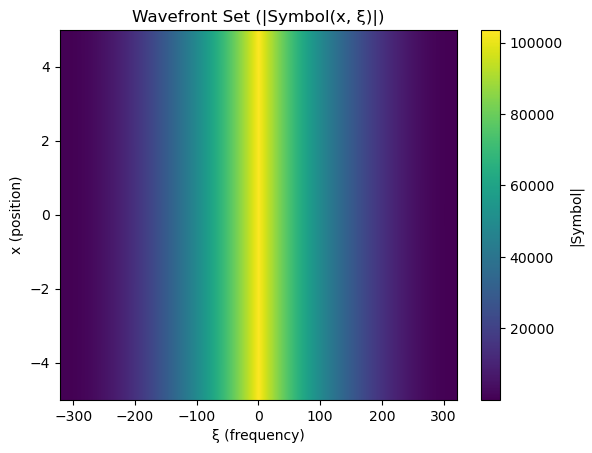

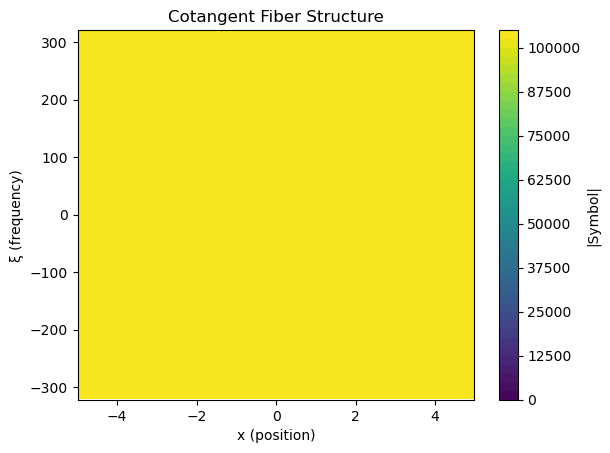

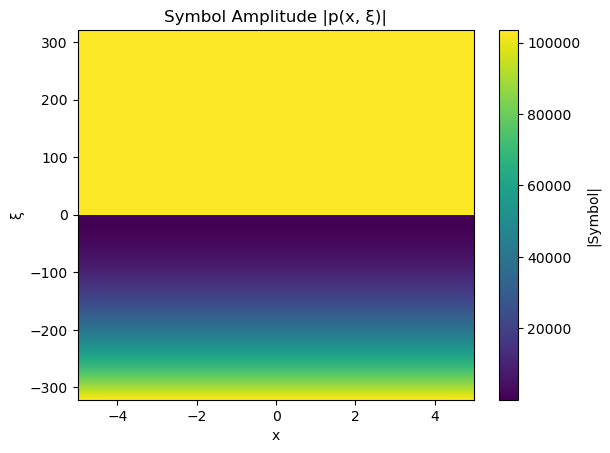

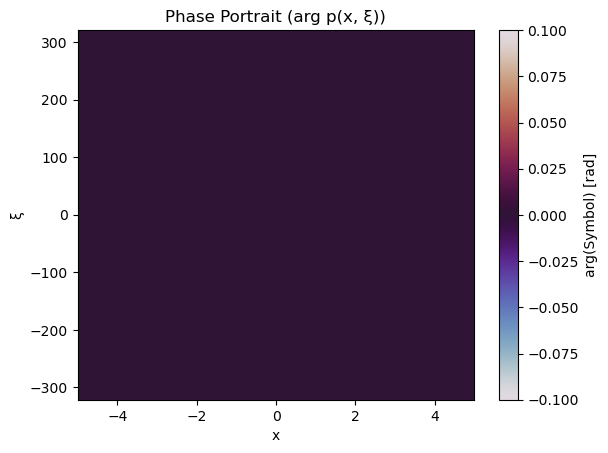

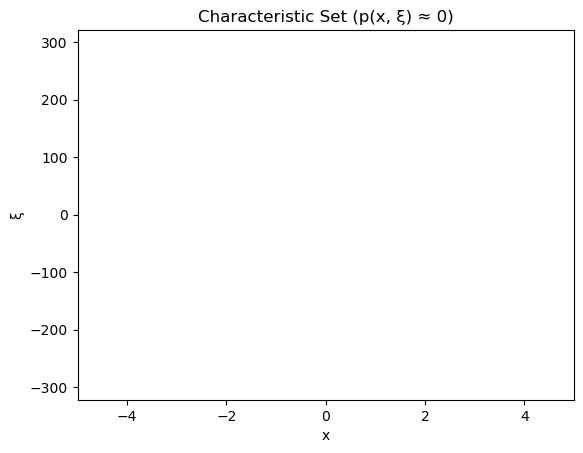

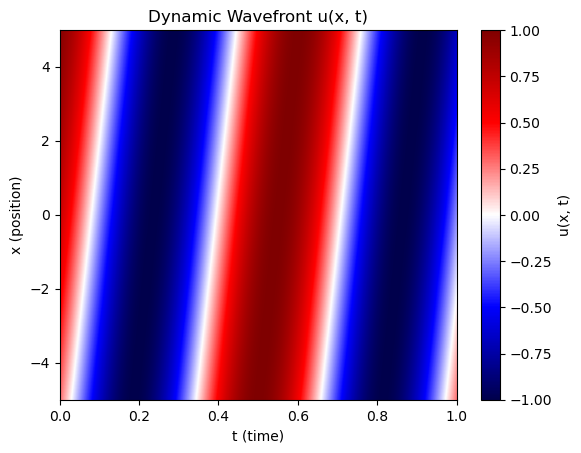

Relative Error: 4.51e-09


/home/fifi/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fifi/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


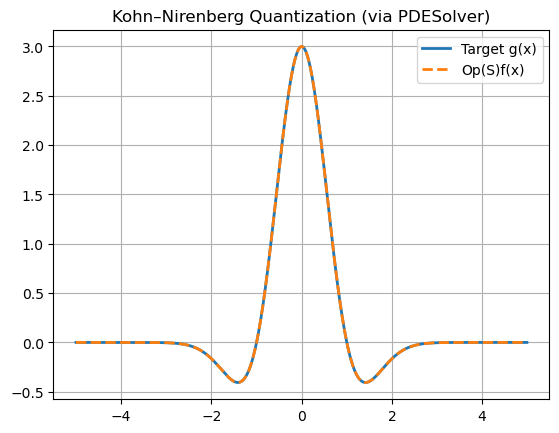

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Eq, symbols, Function

# --- Dummy Equation for Solver Initialization ---
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

equation = Eq(psiOp(x**2 + xi**2 + 1, u), 0)

# --- Initialize Solver ---
solver = PDESolver(equation)
L = 10
N = 1024
solver.setup(Lx=L, Nx=N)

# --- Test Function and Target ---
x_grid = solver.x_grid
f_vals = np.exp(-x_grid**2)
g_vals = 3 * (1 - x_grid**2) * f_vals

# --- Symbol of the Pseudo-Op ---
def S(x, xi):
    return x**2 + xi**2 + 1

# --- Apply Pseudo-Operator ---
g_approx = solver.kohn_nirenberg_fft(f_vals, symbol_func=S)

# --- Relative Error ---
err = np.linalg.norm(g_vals - g_approx) / np.linalg.norm(g_vals)
print(f"Relative Error: {err:.2e}")

# --- Display Results ---
plt.plot(x_grid, g_vals, label='Target g(x)', lw=2)
plt.plot(x_grid, g_approx, '--', label='Op(S)f(x)', lw=2)
plt.legend()
plt.grid(True)
plt.title("Kohn–Nirenberg Quantization (via PDESolver)")
plt.show()



*********************************
* Partial differential equation *
*********************************

     ⎛ 2    2          ⎞    
psiOp⎝x  + ξ  + 1, u(x)⎠ = 0

********************
* Equation parsing *
********************


Equation rewritten in standard form: psiOp(x**2 + xi**2 + 1, u(x))

Expanded equation: psiOp(x**2 + xi**2 + 1, u(x))
Analyzing term: psiOp(x**2 + xi**2 + 1, u(x))
  --> Classified as pseudo linear term (psiOp)
Final linear terms: {}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, x**2 + xi**2 + 1)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

symbol = 
 2    2    
x  + ξ  + 1

symbol = 
 2    2    
x  + ξ  + 1


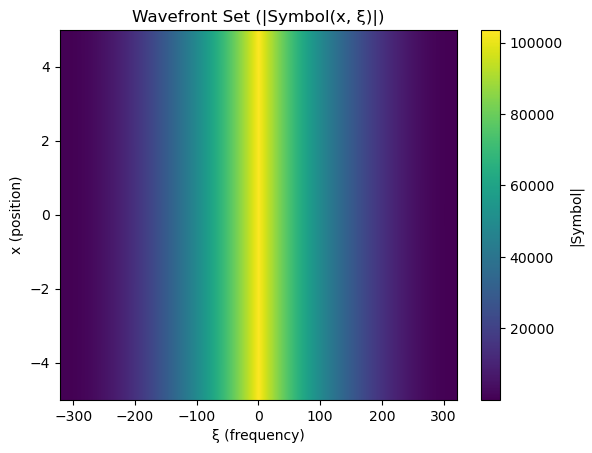

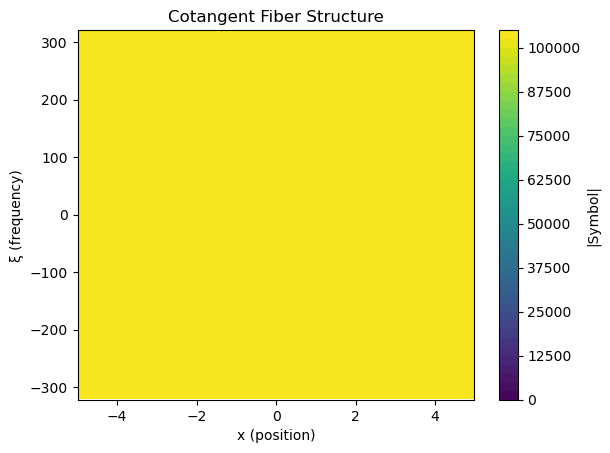

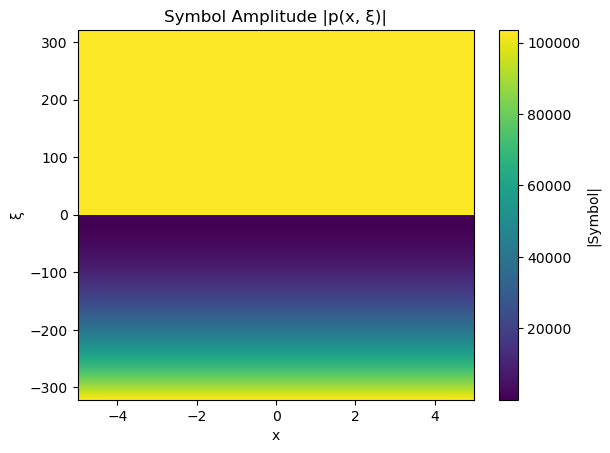

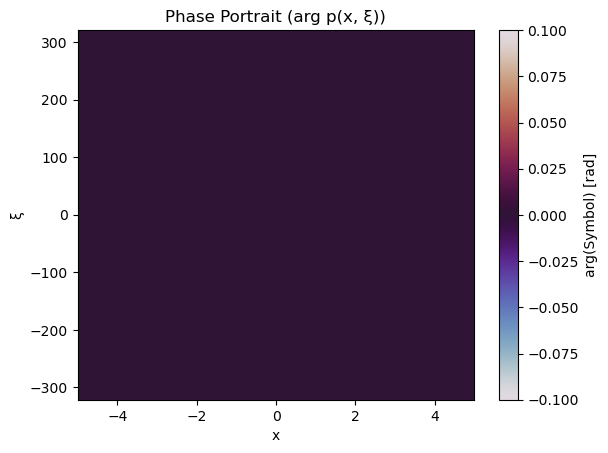

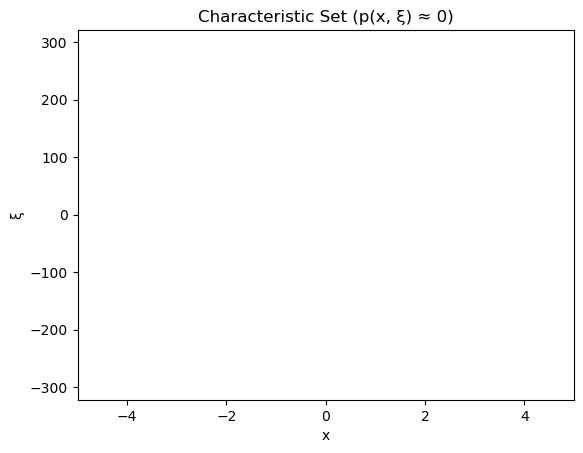

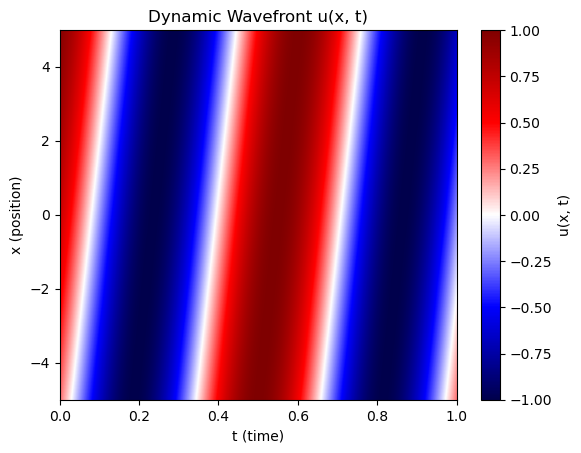

Relative Error: 4.51e-09


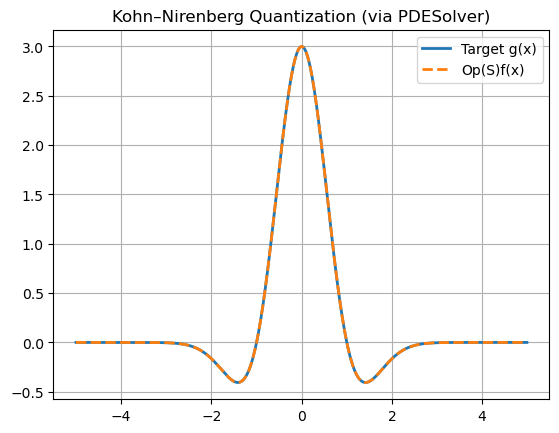

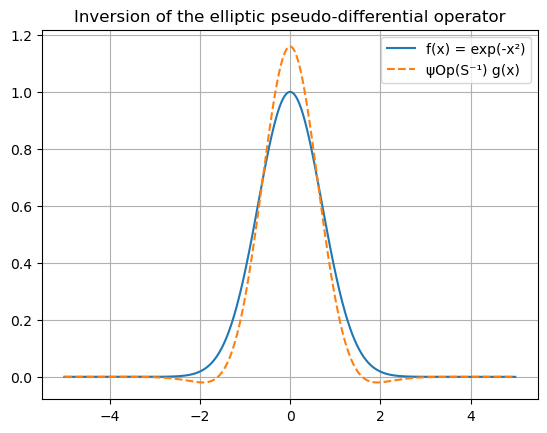

Relative error: 1.59e-01


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Eq, symbols, Function

# --- Dummy Equation for Solver Initialization ---
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

equation = Eq(psiOp(x**2 + xi**2 + 1, u), 0)

# --- Initialize Solver ---
solver = PDESolver(equation)
L = 10
N = 1024
solver.setup(Lx=L, Nx=N)

# --- Test Function and Target ---
x_grid = solver.x_grid
f_vals = np.exp(-x_grid**2)
g_vals = 3 * (1 - x_grid**2) * f_vals

# --- Symbol of the Pseudo-Op ---
def S(x, xi):
    return x**2 + xi**2 + 1

# --- Apply Pseudo-Operator ---
g_approx = solver.kohn_nirenberg_fft(f_vals, symbol_func=S)

# --- Relative Error ---
err = np.linalg.norm(g_vals - g_approx) / np.linalg.norm(g_vals)
print(f"Relative Error: {err:.2e}")

# --- Display Results ---
plt.plot(x_grid, g_vals, label='Target g(x)', lw=2)
plt.plot(x_grid, g_approx, '--', label='Op(S)f(x)', lw=2)
plt.legend()
plt.grid(True)
plt.title("Kohn–Nirenberg Quantization (via PDESolver)")
plt.show()


def S_inv(x, xi):
    return 1.0 / (S(x, xi) + 1e-10)  # Small regularization

f_approx = solver.kohn_nirenberg_fft(g_approx, S_inv)

plt.plot(x_grid, f_vals, label='f(x) = exp(-x²)')
plt.plot(x_grid, f_approx, '--', label='ψOp(S⁻¹) g(x)')
plt.legend()
plt.title("Inversion of the elliptic pseudo-differential operator")
plt.grid(True)
plt.show()

err = np.linalg.norm(f_approx - f_vals) / np.linalg.norm(f_vals)
print(f"Relative error: {err:.2e}")
